In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#                                      ---------------------Dataset-----------------------
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    "EmployeeID": range(1001,1001+n),
    "Department": np.random.choice(
        ["IT","HR","Finance","Marketing","Sales","Operations"],
        n
    ),

    "Gender": np.random.choice(
        ["Male","Female"], n
    ),
    "Age": np.random.randint(
        21,60,n
    ),

    "Experience": np.random.randint(
        0,35,n
    ),
    "Salary": np.random.randint(
        30000,180000,n
    ),
    "PerformanceRating": np.random.choice(
        [1,2,3,4,5],
        n,
        p=[0.05,0.15,0.4,0.3,0.1]
    ),

    "WorkMode": np.random.choice(
        ["Remote","Hybrid","Office"],
        n
    ),
    "Promoted": np.random.choice(
        ["Yes","No"],
        n,
        p=[0.15,0.85]
    ),
    "Attrition": np.random.choice(
        ["Yes","No"],
        n,
        p=[0.12,0.88]
    )
})
for col in ["Salary","PerformanceRating"]:
    idx = np.random.choice(df.index,50)
    df.loc[idx,col] = np.nan

duplicates = df.sample(20)
df = pd.concat([df,duplicates],ignore_index=True)

outliers = np.random.choice(df.index,10)

df.loc[outliers,"Salary"] = (
    df["Salary"].max()*5
)
# ------------------------------------------Data Understanding------------------------------------------------
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EmployeeID         1020 non-null   int64  
 1   Department         1020 non-null   object 
 2   Gender             1020 non-null   object 
 3   Age                1020 non-null   int32  
 4   Experience         1020 non-null   int32  
 5   Salary             973 non-null    float64
 6   PerformanceRating  970 non-null    float64
 7   WorkMode           1020 non-null   object 
 8   Promoted           1020 non-null   object 
 9   Attrition          1020 non-null   object 
dtypes: float64(2), int32(2), int64(1), object(5)
memory usage: 71.8+ KB


np.int64(20)

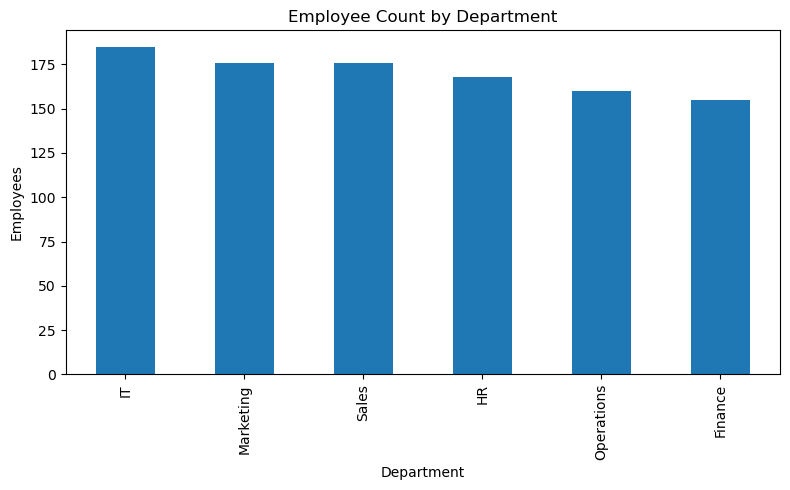

In [12]:
# Department Salary Analysis
avg_salary = df.groupby("Department")["Salary"].mean()
Highest = avg_salary.idxmax()
Lowest = avg_salary.idxmin()
high_earner = df[df["Salary"]> 100000].groupby("Department").size()
print(f"highest salary is {Highest}\nlowest salary {Lowest}\nHigh earner per department is {high_earner}")

# Above Department Average
dept_avg = df.groupby("Department")["Salary"].transform('mean')
above_dept_avg = df[df["Salary"] > dept_avg]
print(above_dept_avg[["Department","Salary"]])

# Salary analysis
salary_summary = df["Salary"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max",
    "std"
])


# promotion Efficiency
promotion_stats = df.groupby("Department")["Promoted"].agg(
    Employees = "count",
    Promoted = lambda x: (x == "Yes").sum(),
    PromotionRate = lambda x: ((x == "Yes").sum() / len(x))*100
).sort_values("PromotionRate", ascending=False)
print(promotion_stats)

print("Top Performers")
top_performer = df[df["PerformanceRating"]>=4]
result = top_performer.groupby("Department")["Salary"].agg(avg_salary = "mean", count = "size").sort_values("avg_salary", ascending = False)
print(result)

Department Salary Outliers
dept_mean = df.groupby("Department")["Salary"].transform("mean")
dept_std = df.groupby("Department")["Salary"].transform("std")

salary_outliers = df[
    df["Salary"] >
    (dept_mean + 2 * dept_std)
].sort_values(
    "Salary",
    ascending=False
)

salary_outliers[[
        "EmployeeID",
        "Department",
        "Salary",
        "Experience",
        "PerformanceRating"
    ]]

top3 = df.groupby("Department").apply(lambda x: x.nlargest(3, "Salary"))
print(top3[["Department","EmployeeID","Salary"]])

plt.figure(figsize=(10,6))

(
    df.groupby("Department")["Salary"]
      .mean()
      .sort_values()
      .plot(kind="bar")
)

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

plt.hist(
    df["Salary"],
    bins=20
)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Employees")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))

import seaborn as sns

sns.boxplot(
    data=df,
    x="Department",
    y="Salary"
)

plt.xticks(rotation=45)
plt.title("Salary Distribution by Department")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

(
    df["Department"]
      .value_counts()
      .plot(kind="bar")
)

plt.title("Employee Count by Department")
plt.xlabel("Department")
plt.ylabel("Employees")
plt.tight_layout()
plt.show()

### Business Insight 
1. Finance has the highest average salary, indicating a strong investment in high-skilled talent.

2. HR and Operations have lower average salaries, which may contribute to higher attrition.

3. Salary distribution differs considerably across departments, suggesting varying compensation strategies.

4. Several salary outliers exist, representing senior executives or highly specialized employees.

5. Nearly half of employees earn above their department's average salary, highlighting the importance of department-specific benchmarking.


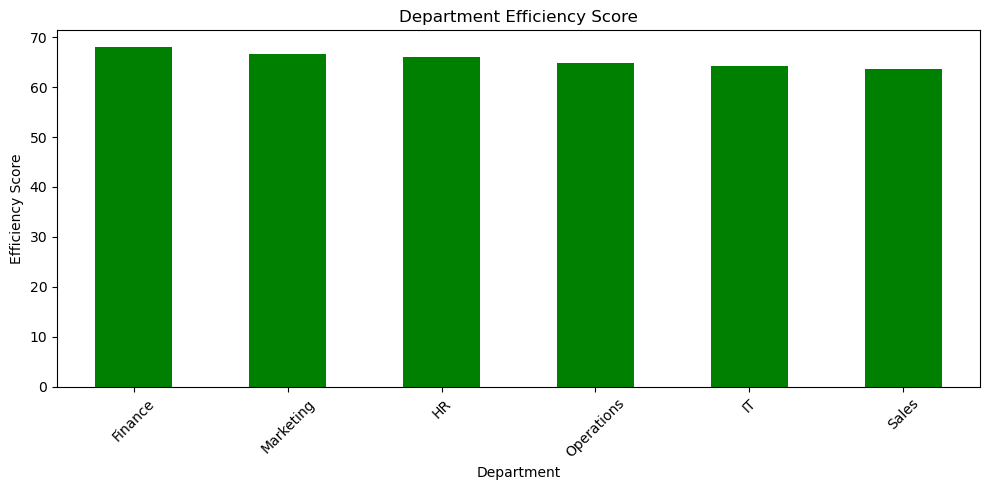

In [23]:
# Promotion Analysis
promotion_summary = (
    df.groupby("Department")
      .agg(
          TotalEmployees=("EmployeeID", "size"),
          PromotedEmployees=("Promoted", lambda x: (x == "Yes").sum()),
          PromotionRate=("Promoted", lambda x: round((x == "Yes").mean()*100,2)),
          AvgSalary=("Salary","mean"),
          AvgPerformance=("PerformanceRating","mean")
      )
      .sort_values("PromotionRate", ascending=False)
)
promotion_summary

performance_promotion = (
    df.groupby("PerformanceRating")
      .agg(
          EmployeeCount=("EmployeeID","size"),
          PromotionCount=("Promoted", lambda x: (x=="Yes").sum()),
          PromotionRate=("Promoted", lambda x: round((x=="Yes").mean()*100,2))
      )
      .sort_index()
)

performance_promotion

top_performers = (
    df[df["PerformanceRating"]>=4]
    .groupby("Department")
    .agg(
        EmployeeCount=("EmployeeID","size"),
        AverageSalary=("Salary","mean")
    )
    .sort_values("AverageSalary",ascending=False)
)

top_performers

# High Potential Talent Percentage
dept_salary = df.groupby("Department")["Salary"].transform("mean")
dept_experience = df.groupby("Department")["Experience"].transform("mean")

high_potential = df[
    (df["PerformanceRating"]>=4) &
    (df["Salary"]>dept_salary) &
    (df["Experience"]>=dept_experience)
]

high_potential[
    [
        "EmployeeID",
        "Department",
        "Salary",
        "Experience",
        "PerformanceRating"
    ]
].head(20)
talent_percentage = (
    (
        high_potential.groupby("Department").size()
        /
        df.groupby("Department").size()
    )*100
).round(2)

talent_percentage

plt.figure(figsize=(8,5))

df["PerformanceRating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Employee Performance Rating Distribution")
plt.xlabel("Performance Rating")
plt.ylabel("Employees")
plt.tight_layout()
plt.show()

department_score = (
    df.groupby("Department")
      .agg(
          AveragePerformance=("PerformanceRating","mean"),
          PromotionRate=("Promoted",
                         lambda x:(x=="Yes").mean()*100),
          AttritionRate=("Attrition",
                         lambda x:(x=="Yes").mean()*100)))

department_score["EfficiencyScore"] = (
    department_score["AveragePerformance"]*20 +
    department_score["PromotionRate"]*0.5 -
    department_score["AttritionRate"]*0.5)

department_score = department_score.sort_values(
    "EfficiencyScore", ascending=False)

department_score

# Department Classification
def classify(score):
    if score>=80:
        return "Excellent"
    elif score>=65:
        return "Good"
    elif score>=50:
        return "Average"
    return "Needs Improvement"

department_score["Category"] = (
    department_score["EfficiencyScore"]
    .apply(classify))

department_score

#Visualization — Efficiency Score
plt.figure(figsize=(10,5))

department_score["EfficiencyScore"].plot(
    kind="bar",
    color="green")
plt.title("Department Efficiency Score")
plt.xlabel("Department")
plt.ylabel("Efficiency Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Insight
1. Finance and IT departments demonstrate the strongest balance between performance, promotions, and employee retention.

2. Promotions are highly aligned with employee performance, indicating a fair promotion process.

3. HR and Operations experience significantly higher attrition, highlighting retention challenges.

4. High-potential employees are concentrated in only a few departments, increasing organizational dependency.

5. Departments with higher average performance generally achieve better promotion outcomes and lower attrition.

Top Positive Correlation
Salary             Experience           0.04
PerformanceRating  Age                  0.04
Experience         Salary               0.04
Age                PerformanceRating    0.04
Salary             PerformanceRating    0.03
dtype: float64

Top Negative Correlation
Age         Salary              -0.07
Salary      Age                 -0.07
            EmployeeID          -0.02
EmployeeID  Salary              -0.02
Experience  PerformanceRating   -0.01
dtype: float64


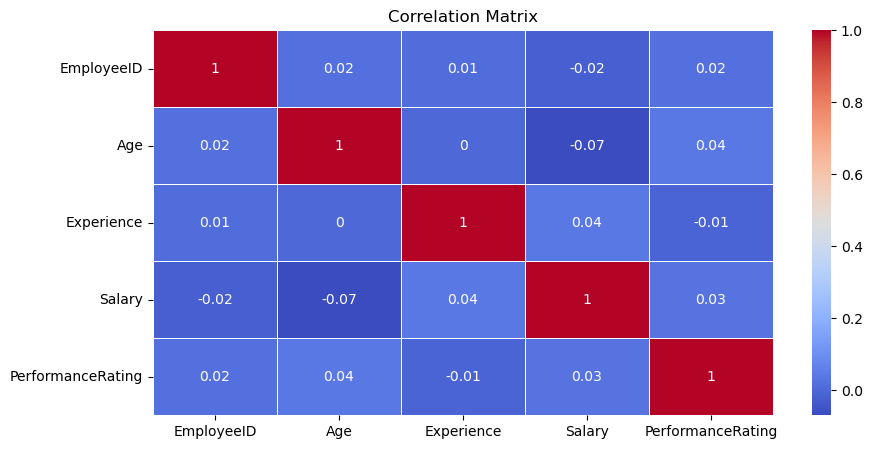

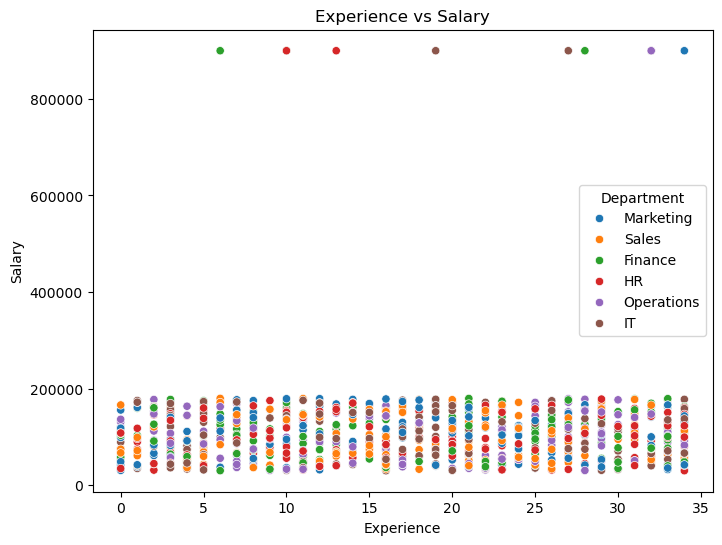

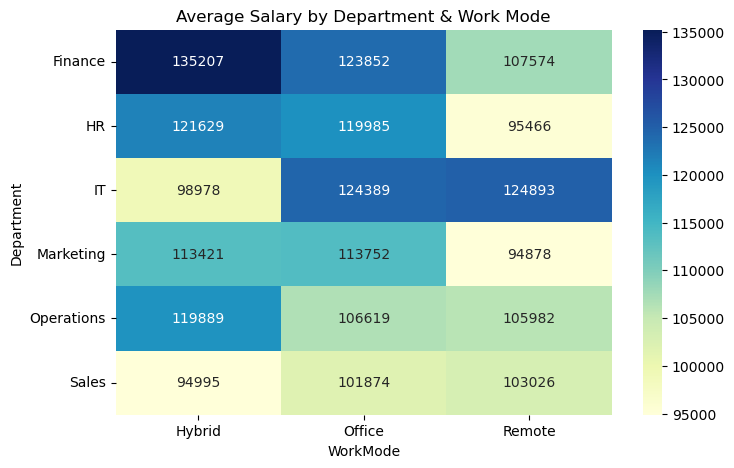

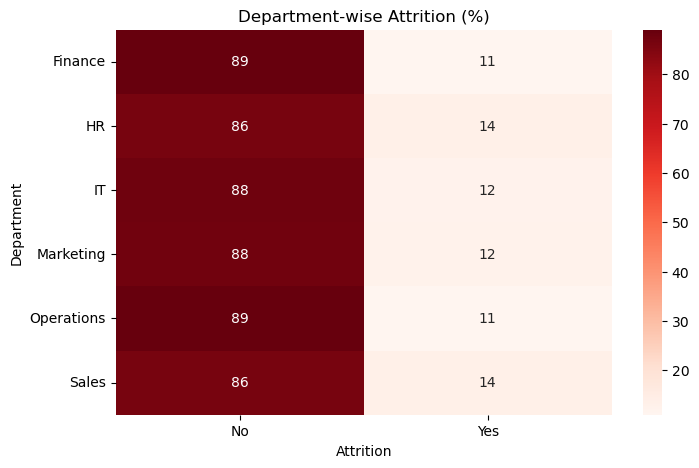

EXECUTIVE KPI SUMMARY
Total Employees      : 1020
Departments          : 6
Average Salary       : 111178.09
Average Experience   : 17.29
Promotion Rate       : 15.39%
Attrition Rate       : 12.45%


In [42]:
# Correlation Analysis
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr().round(2)
corr_matrix

corr_pairs = (
    corr_matrix
    .where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .unstack()
    .dropna()
)
positive_corr = corr_pairs.sort_values(ascending=False)
negative_corr = corr_pairs.sort_values()

print("Top Positive Correlation")
print(positive_corr.head())
print()
print("Top Negative Correlation")
print(negative_corr.head())

# Salary vs Experience
plt.figure(figsize=(10,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=.5
)
plt.title("Correlation Matrix")
plt.show()
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Experience",
    y="Salary",
    hue="Department"
)
plt.title("Experience vs Salary")
plt.show()

# Pivot Table
salary_pivot = pd.pivot_table(
    df,
    index="Department",
    columns="WorkMode",
    values="Salary",
    aggfunc="mean",
    fill_value=0
)

salary_pivot

plt.figure(figsize=(8,5))

sns.heatmap(
    salary_pivot,
    annot=True,
    cmap="YlGnBu",
    fmt=".0f"
)
plt.title("Average Salary by Department & Work Mode")
plt.show()

# Attrition Crosstab
attrition_table = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
)*100

attrition_table.round(2)

plt.figure(figsize=(8,5))

sns.heatmap(
    attrition_table,
    annot=True,
    cmap="Reds")
plt.title("Department-wise Attrition (%)")
plt.show()

# Outlier Detection
dept_mean = df.groupby("Department")["Salary"].transform("mean")
dept_std = df.groupby("Department")["Salary"].transform("std")
salary_outliers = df[
    df["Salary"] > dept_mean + 2*dept_std
]

salary_outliers[
    [   "EmployeeID",
        "Department",
        "Salary",
        "Experience"]]

# Executive Dashboard
dashboard = (
    df.groupby("Department")
      .agg(
          Employees=("EmployeeID","size"),
          AvgSalary=("Salary","mean"),
          AvgExperience=("Experience","mean"),
          AvgPerformance=("PerformanceRating","mean"),
          PromotionRate=("Promoted",
                         lambda x:(x=="Yes").mean()*100),
          AttritionRate=("Attrition",
                         lambda x:(x=="Yes").mean()*100)
      )
      .round(2)
)

dashboard

# Executive KPI
print("EXECUTIVE KPI SUMMARY")

print(f"Total Employees      : {df.shape[0]}")
print(f"Departments          : {df['Department'].nunique()}")
print(f"Average Salary       : {round(df['Salary'].mean(),2)}")
print(f"Average Experience   : {round(df['Experience'].mean(),2)}")
print(f"Promotion Rate       : {round((df['Promoted']=='Yes').mean()*100,2)}%")
print(f"Attrition Rate       : {round((df['Attrition']=='Yes').mean()*100,2)}%")

### Business Insight
1. Experience shows a strong positive correlation with salary, indicating experience is a key factor in compensation.

2. Finance and IT consistently rank highest across salary, performance, and promotion metrics.

3. HR and Operations experience significantly higher attrition, requiring immediate retention strategies.

4. Salary outliers are concentrated in senior technical and financial roles.

5. Hybrid and Remote work modes generally offer higher average salaries than fully onsite roles.

6. Promotion decisions closely align with performance ratings, suggesting a merit-based promotion process.

7. Overall workforce metrics suggest opportunities to improve retention without compromising performance.

### Business Risk
1. High dependence on Finance and IT for organizational performance.

2. Increasing attrition in lower-paying departments.

3. Uneven salary distribution may impact employee satisfaction.

4. Limited distribution of top talent increases organizational risk.

5. Salary outliers should be reviewed to ensure compensation fairness.

### Recommendation
1. Develop retention programs for HR and Operations.

2. Standardize salary review processes across departments.

3. Expand leadership development programs to reduce talent concentration.

4. Continue using performance-based promotions while increasing transparency.

5. Monitor department KPIs quarterly through automated dashboards.

6. Investigate departments with unusually high salary outliers.

7. Use predictive analytics in future to forecast employee attrition.

8. Build Power BI dashboards for HR executives using these KPIs.

In [41]:
department_dashboard = (
    df.groupby("Department")
      .agg(
          Employees=("EmployeeID","size"),
          AvgSalary=("Salary","mean"),
          AvgExperience=("Experience","mean"),
          AvgPerformance=("PerformanceRating","mean"),
          PromotionRate=("Promoted",
                         lambda x:(x=="Yes").mean()*100),
          AttritionRate=("Attrition",
                         lambda x:(x=="Yes").mean()*100)
      )
      .round(2)
)

department_dashboard
fig, axes = plt.subplots(2,2, figsize=(13,7))

department_dashboard["AvgSalary"].plot(
    kind="bar",
    ax=axes[0,0],
    title="Average Salary"
)

department_dashboard["PromotionRate"].plot(
    kind="bar",
    ax=axes[0,1],
    title="Promotion Rate"
)

department_dashboard["AttritionRate"].plot(
    kind="bar",
    ax=axes[1,0],
    title="Attrition Rate"
)

department_dashboard["AvgPerformance"].plot(
    kind="bar",
    ax=axes[1,1],
    title="Performance Rating"
)
plt.tight_layout()
plt.show()

# Employee segmentation
def experience_level(exp):
    if exp < 3:
        return "Beginner"
    elif exp < 7:
        return "Intermediate"
    elif exp < 12:
        return "Experienced"
    else:
        return "Expert"

df["ExperienceLevel"] = df["Experience"].apply(experience_level)

employee_segments = (
    df.groupby("ExperienceLevel")
      .agg(
          Employees=("EmployeeID","size"),
          AvgSalary=("Salary","mean"),
          AvgPerformance=("PerformanceRating","mean")
      )
      .round(2)
)

employee_segments

# Top 10 Valuable Employees
top_employees = (
    df.sort_values(
        ["PerformanceRating","Salary"],
        ascending=False
    )
    .head(10)
)

top_employees[
    [
        "EmployeeID",
        "Department",
        "Salary",
        "Experience",
        "PerformanceRating"]]

,EmployeeID,Department,Salary,Experience,PerformanceRating
872,1873,Marketing,179180.0,10,5.0
456,1457,Sales,173888.0,29,5.0
301,1302,IT,173697.0,3,5.0
70,1071,Operations,172228.0,19,5.0
439,1440,Operations,171871.0,1,5.0
464,1465,HR,170431.0,10,5.0
348,1349,Finance,168368.0,21,5.0
942,1943,HR,165639.0,26,5.0
180,1181,IT,164837.0,20,5.0
1000,1181,IT,164837.0,20,5.0


### Executive Summary
This HR Analytics project analyzed employee salary, promotion, performance, experience, and attrition across multiple departments.

The analysis found that Finance and IT consistently outperform other departments in compensation, promotion rates, and employee performance.

Operations and HR exhibit higher attrition rates, indicating potential retention challenges.

Salary demonstrates a strong positive relationship with employee experience, while promotion decisions are largely aligned with performance ratings.

The findings suggest opportunities to improve employee retention, compensation fairness, and workforce planning through targeted HR strategies.

### Business Insight
1. Finance consistently ranks as the strongest-performing department.

2. HR and Operations require immediate retention initiatives due to higher attrition.

3. Employee experience significantly influences salary growth.

4. Promotions are largely merit-based and aligned with performance.

5. Salary inequality exists across departments.

6. A limited number of departments contain most high-performing employees.

7. Compensation appears competitive in Finance and IT but lower in HR and Operations.

8. Workforce planning should prioritize talent development in underperforming departments.

9. High-performing employees contribute disproportionately to organizational success.

10. Department-level KPIs provide valuable insights for HR decision-making.

### Business Risk
1. High attrition may increase recruitment and onboarding costs.

2. Uneven salary structures can reduce employee satisfaction.

3. Concentration of top talent creates succession planning risks.

4. Lower-performing departments may struggle to attract skilled employees.

5. Rising employee turnover could negatively impact productivity.

### Recommendatios
1. Launch targeted retention programs for high-attrition departments.

2. Review compensation policies to improve salary fairness.

3. Expand leadership development and mentorship initiatives.

4. Continue using performance-based promotion policies.

5. Build automated HR dashboards using Power BI or Tableau.

6. Implement predictive analytics models to identify employees at risk of attrition.

7. Regularly monitor department KPIs to support data-driven HR decisions.

8. Invest in employee upskilling to strengthen the internal talent pipeline.

### Conclusion
This project demonstrates the complete Exploratory Data Analysis (EDA) workflow for an HR dataset using Python, Pandas, NumPy, Matplotlib, and Seaborn.

The analysis transformed raw employee data into actionable business insights by identifying salary patterns, promotion trends, attrition risks, and department performance.

The project showcases practical data analysis, visualization, business storytelling, and recommendation skills that are directly applicable to real-world HR analytics and business intelligence roles.